# **Dataset Loading**

In [68]:
!mkdir -p ~/.kaggle
!echo KGAT_6968f1c14d49958bb6ea5efff1fbd774 > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [69]:
!kaggle --version

Kaggle CLI 2.0.2


In [70]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
Resuming from 57671680 bytes (2405693755 bytes left)...
100% 2.29G/2.29G [01:44<00:00, 23.1MB/s]



In [71]:
import zipfile
import os

zip_path = "/content/chest-xray-pneumonia.zip"

extract_path = "/content/chest_xray"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [72]:
import os

dataset_path = "/content/chest_xray/chest_xray"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = " " * 4 * level
    print(indent + os.path.basename(root) + "/")
    if level < 2:
        for file in files[:3]:
            print(indent + "    " + file)

chest_xray/
    chest_xray/
        .DS_Store
        train/
            PNEUMONIA/
            NORMAL/
        val/
            PNEUMONIA/
            NORMAL/
        test/
            PNEUMONIA/
            NORMAL/
    train/
        PNEUMONIA/
        NORMAL/
    val/
        PNEUMONIA/
        NORMAL/
    test/
        PNEUMONIA/
        NORMAL/
    __MACOSX/
        ._chest_xray
        chest_xray/
            train/
                PNEUMONIA/
                NORMAL/
            val/
                PNEUMONIA/
                NORMAL/
            test/
                PNEUMONIA/
                NORMAL/


In [73]:
import os

splits = ["train", "val", "test"]

for split in splits:
    print("\n", split)

    for label in ["NORMAL", "PNEUMONIA"]:
        path = os.path.join(
            dataset_path,
            split,
            label
        )

        count = len(os.listdir(path))

        print(label, ":", count)


 train
NORMAL : 1341
PNEUMONIA : 3875

 val
NORMAL : 8
PNEUMONIA : 8

 test
NORMAL : 234
PNEUMONIA : 390


# **Dataset Understanding (EDA)**

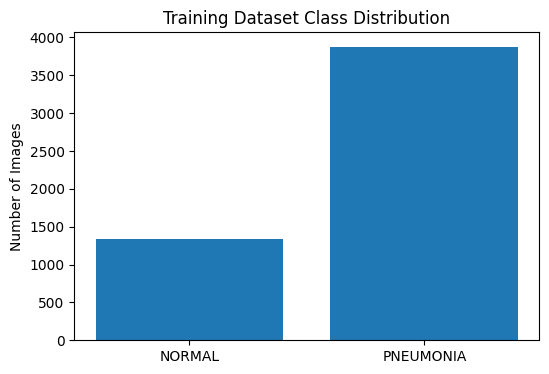

In [74]:
import matplotlib.pyplot as plt

train_normal = len(
    os.listdir(dataset_path+"/train/NORMAL")
)

train_pneumonia = len(
    os.listdir(dataset_path+"/train/PNEUMONIA")
)


classes = ["NORMAL", "PNEUMONIA"]
counts = [train_normal, train_pneumonia]


plt.figure(figsize=(6,4))

plt.bar(classes, counts)

plt.title("Training Dataset Class Distribution")
plt.ylabel("Number of Images")

plt.show()

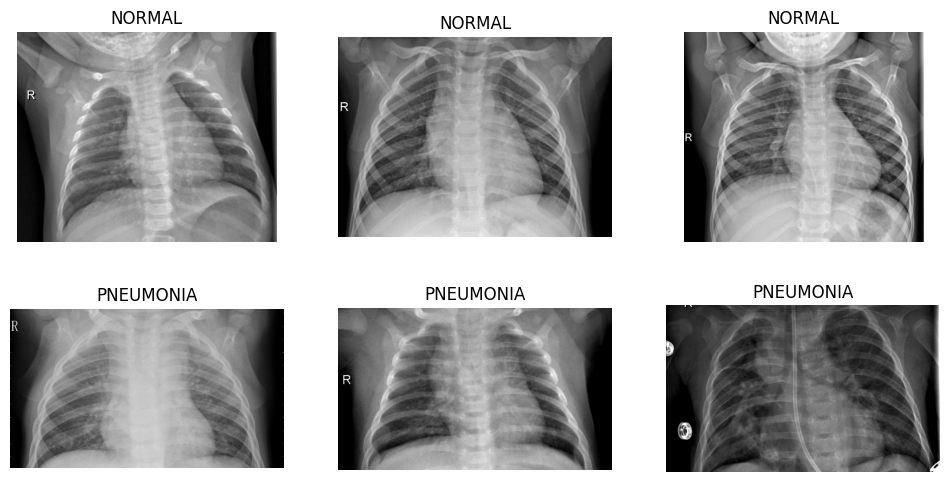

In [75]:
import matplotlib.pyplot as plt
import random
import cv2


normal_path = dataset_path + "/train/NORMAL"
pneumonia_path = dataset_path + "/train/PNEUMONIA"


normal_images = os.listdir(normal_path)
pneumonia_images = os.listdir(pneumonia_path)


plt.figure(figsize=(12,6))


for i in range(3):

    img_name = random.choice(normal_images)

    img = cv2.imread(
        normal_path+"/"+img_name,
        cv2.IMREAD_GRAYSCALE
    )

    plt.subplot(2,3,i+1)
    plt.imshow(img,cmap="gray")
    plt.title("NORMAL")
    plt.axis("off")


for i in range(3):

    img_name = random.choice(pneumonia_images)

    img = cv2.imread(
        pneumonia_path+"/"+img_name,
        cv2.IMREAD_GRAYSCALE
    )

    plt.subplot(2,3,i+4)
    plt.imshow(img,cmap="gray")
    plt.title("PNEUMONIA")
    plt.axis("off")


plt.show()

In [76]:
from PIL import Image
import random


img_name = random.choice(normal_images)

img_path = normal_path + "/" + img_name


img = Image.open(img_path)


print("Image size:", img.size)
print("Image mode:", img.mode)

Image size: (1396, 1001)
Image mode: L


# **Data Preprocessing**

In [77]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

In [78]:
dataset_path = "/content/chest_xray/chest_xray"

train_path = os.path.join(dataset_path, "train")

normal_path = os.path.join(train_path, "NORMAL")
pneumonia_path = os.path.join(train_path, "PNEUMONIA")

In [79]:
images = []
labels = []


# NORMAL = 0
for img in os.listdir(normal_path):
    images.append(
        os.path.join(normal_path, img)
    )
    labels.append(0)



# PNEUMONIA = 1
for img in os.listdir(pneumonia_path):
    images.append(
        os.path.join(pneumonia_path, img)
    )
    labels.append(1)



print("Total images:", len(images))
print("Total labels:", len(labels))

Total images: 5216
Total labels: 5216


In [80]:
X_train, X_val, y_train, y_val = train_test_split(
    images,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)


print("Train:", len(X_train))
print("Validation:", len(X_val))

Train: 4172
Validation: 1044


In [81]:
from collections import Counter


print("Train distribution:")
print(Counter(y_train))


print("\nValidation distribution:")
print(Counter(y_val))

Train distribution:
Counter({1: 3099, 0: 1073})

Validation distribution:
Counter({1: 776, 0: 268})


In [82]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32

In [83]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=15,

    zoom_range=0.1,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True
)



val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [84]:
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.image import load_img, img_to_array


class XRayGenerator(Sequence):

    def __init__(
        self,
        image_paths,
        labels,
        batch_size,
        augment=False
    ):

        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment


    def __len__(self):

        return len(self.image_paths)//self.batch_size



    def __getitem__(self,index):

        batch_paths = self.image_paths[
            index*self.batch_size:
            (index+1)*self.batch_size
        ]

        batch_labels = self.labels[
            index*self.batch_size:
            (index+1)*self.batch_size
        ]


        images = []


        for path in batch_paths:

            img = load_img(
                path,
                target_size=IMG_SIZE,
                color_mode="rgb"
            )

            img = img_to_array(img)

            img = img/255.0


            images.append(img)


        return (
            np.array(images),
            np.array(batch_labels)
        )

In [85]:
train_generator = XRayGenerator(
    X_train,
    y_train,
    BATCH_SIZE
)


val_generator = XRayGenerator(
    X_val,
    y_val,
    BATCH_SIZE
)

In [86]:
images_batch, labels_batch = train_generator[0]


print(images_batch.shape)
print(labels_batch.shape)

(32, 224, 224, 3)
(32,)


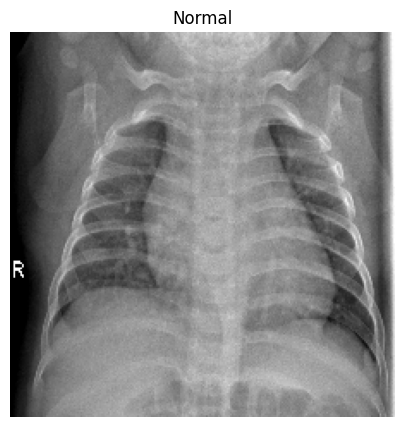

In [87]:
plt.figure(figsize=(5,5))

plt.imshow(images_batch[0])

plt.title(
    "Pneumonia"
    if labels_batch[0]==1
    else "Normal"
)

plt.axis("off")

plt.show()

# **Classification Model**

In [100]:
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.applications import DenseNet121

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.utils import class_weight
import numpy as np

In [101]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [102]:
base_model.trainable = False

In [103]:
x = base_model.output


x = GlobalAveragePooling2D()(x)


x = Dense(
    256,
    activation="relu"
)(x)


x = Dropout(0.5)(x)


output = Dense(
    1,
    activation="sigmoid"
)(x)



model = Model(
    inputs=base_model.input,
    outputs=output
)

In [104]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [105]:
from tensorflow.keras.optimizers import AdamW

model.compile(
    optimizer=AdamW(
        learning_rate=1e-4,
        weight_decay=1e-5
    ),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),

        tf.keras.metrics.Precision(name="precision"),

        tf.keras.metrics.Recall(name="recall"),

        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        ),

        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

In [106]:
from sklearn.utils import class_weight
import numpy as np


weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)


class_weights = dict(zip(
    np.unique(y_train),
    weights
))


class_weights[1] *= 1.3


print(class_weights)

{np.int64(0): np.float64(1.9440820130475303), np.int64(1): np.float64(0.8750564698289771)}


In [107]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger,
    TensorBoard
)

import datetime


log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")


callbacks = [

    EarlyStopping(
        monitor="val_pr_auc",
        patience=10,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),


    ReduceLROnPlateau(
        monitor="val_pr_auc",
        factor=0.2,
        patience=4,
        mode="max",
        min_lr=1e-7,
        verbose=1
    ),


    ModelCheckpoint(
        filepath="best_densenet121_pneumonia.keras",
        monitor="val_pr_auc",
        save_best_only=True,
        save_weights_only=False,
        mode="max",
        verbose=1
    ),


    CSVLogger(
        "training_history.csv",
        append=True
    ),


    TensorBoard(
        log_dir=log_dir,
        histogram_freq=1
    )
]

In [108]:
import math

history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=50,


    class_weight=class_weights,


    steps_per_epoch=len(train_generator),

    validation_steps=len(val_generator),


    callbacks=callbacks,


    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.7450 - loss: 0.6025 - pr_auc: 0.9133 - precision: 0.8746 - recall: 0.7636 - roc_auc: 0.8045
Epoch 1: val_pr_auc improved from None to 0.99037, saving model to best_densenet121_pneumonia.keras

Epoch 1: finished saving model to best_densenet121_pneumonia.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 108s 586ms/step - accuracy: 0.8245 - loss: 0.4506 - pr_auc: 0.9631 - precision: 0.9193 - recall: 0.8372 - roc_auc: 0.9029 - val_accuracy: 0.9189 - val_loss: 0.2068 - val_pr_auc: 0.9904 - val_precision: 0.9593 - val_recall: 0.9303 - val_roc_auc: 0.9729 - learning_rate: 1.0000e-04
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.8922 - loss: 0.2896 - pr_auc: 0.9874 - precision: 0.9582 - recall: 0.8930 - roc_auc: 0.9621
Epoch 2: val_pr_auc improved from 0.99037 to 0.99310, saving model to best_densenet121_pneumonia.keras

Epoch 2: finished saving model to best_densenet121_pneumonia.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 59s

In [109]:
base_model.trainable = True

In [110]:
for layer in base_model.layers[:-50]:
    layer.trainable = False

In [111]:
model.compile(

    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-6
    ),

    loss="binary_crossentropy",

    metrics=[

        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        ),

        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

In [113]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger,
    TensorBoard
)

import datetime


# TensorBoard log directory
log_dir = (
    "logs/fine_tune/"
    + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)


fine_tune_callbacks = [

    # Stop if validation performance stops improving
    EarlyStopping(
        monitor="val_pr_auc",
        patience=6,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),


    # Reduce learning rate during plateau
    ReduceLROnPlateau(
        monitor="val_pr_auc",
        factor=0.3,
        patience=2,
        mode="max",
        min_lr=1e-7,
        verbose=1
    ),


    # Save best fine-tuned model
    ModelCheckpoint(
        filepath="best_densenet121_pneumonia_finetuned.keras",
        monitor="val_pr_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),


    # Save training history
    CSVLogger(
        "fine_tuning_history.csv",
        append=True
    ),


    # Monitor training visually
    TensorBoard(
        log_dir=log_dir,
        histogram_freq=1
    )
]

In [114]:
history_fine = model.fit(

    train_generator,

    validation_data=val_generator,


    # Maximum epochs
    epochs=30,


    # Handle class imbalance
    class_weight=class_weights,


    # Explicit steps
    steps_per_epoch=len(train_generator),

    validation_steps=len(val_generator),


    # Fine tuning callbacks
    callbacks=fine_tune_callbacks,


    # Progress output
    verbose=1

)

Epoch 1/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.9386 - loss: 0.3154 - pr_auc: 0.9903 - precision: 0.9353 - recall: 0.9874 - roc_auc: 0.9811
Epoch 1: val_pr_auc improved from None to 0.99662, saving model to best_densenet121_pneumonia_finetuned.keras

Epoch 1: finished saving model to best_densenet121_pneumonia_finetuned.keras
130/130 ━━━━━━━━━━━━━━━━━━━━ 119s 574ms/step - accuracy: 0.9536 - loss: 0.2050 - pr_auc: 0.9938 - precision: 0.9591 - recall: 0.9793 - roc_auc: 0.9868 - val_accuracy: 0.9502 - val_loss: 0.1145 - val_pr_auc: 0.9966 - val_precision: 0.9863 - val_recall: 0.9461 - val_roc_auc: 0.9926 - learning_rate: 1.0000e-05
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.9694 - loss: 0.0920 - pr_auc: 0.9985 - precision: 0.9886 - recall: 0.9696 - roc_auc: 0.9957
Epoch 2: val_pr_auc improved from 0.99662 to 0.99696, saving model to best_densenet121_pneumonia_finetuned.keras

Epoch 2: finished saving model to best_densenet121_pneumonia_finetune

# **Explainable AI (Grad-CAM)**

In [115]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.models import Model

In [116]:
model = tf.keras.models.load_model(
    "best_densenet121_pneumonia_finetuned.keras"
)

In [117]:
for layer in model.layers:
    print(layer.name)

input_layer
zero_padding2d
conv1_conv
conv1_bn
conv1_relu
zero_padding2d_1
pool1
conv2_block1_0_bn
conv2_block1_0_relu
conv2_block1_1_conv
conv2_block1_1_bn
conv2_block1_1_relu
conv2_block1_2_conv
conv2_block1_concat
conv2_block2_0_bn
conv2_block2_0_relu
conv2_block2_1_conv
conv2_block2_1_bn
conv2_block2_1_relu
conv2_block2_2_conv
conv2_block2_concat
conv2_block3_0_bn
conv2_block3_0_relu
conv2_block3_1_conv
conv2_block3_1_bn
conv2_block3_1_relu
conv2_block3_2_conv
conv2_block3_concat
conv2_block4_0_bn
conv2_block4_0_relu
conv2_block4_1_conv
conv2_block4_1_bn
conv2_block4_1_relu
conv2_block4_2_conv
conv2_block4_concat
conv2_block5_0_bn
conv2_block5_0_relu
conv2_block5_1_conv
conv2_block5_1_bn
conv2_block5_1_relu
conv2_block5_2_conv
conv2_block5_concat
conv2_block6_0_bn
conv2_block6_0_relu
conv2_block6_1_conv
conv2_block6_1_bn
conv2_block6_1_relu
conv2_block6_2_conv
conv2_block6_concat
pool2_bn
pool2_relu
pool2_conv
pool2_pool
conv3_block1_0_bn
conv3_block1_0_relu
conv3_block1_1_conv
con

In [129]:
last_conv_layer_name = "conv5_block16_concat"


grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer(last_conv_layer_name).output,
        model.output
    ]
)

In [130]:
def make_gradcam_heatmap(img_array, grad_model):

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        # برای Pneumonia probability
        loss = predictions[:, 0]


    grads = tape.gradient(
        loss,
        conv_outputs
    )


    # Global average pooling روی gradient ها
    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )


    conv_outputs = conv_outputs[0]


    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]


    heatmap = tf.squeeze(heatmap)


    # فقط مقادیر مثبت
    heatmap = tf.maximum(
        heatmap,
        0
    )


    heatmap /= (
        tf.reduce_max(heatmap)
        + 1e-10
    )


    return heatmap.numpy()

In [131]:
import os
import pandas as pd


test_dir = "/content/chest_xray/chest_xray/test"


test_paths = []
test_labels = []


# NORMAL = 0
normal_dir = os.path.join(test_dir, "NORMAL")

for img in os.listdir(normal_dir):

    test_paths.append(
        os.path.join(normal_dir, img)
    )

    test_labels.append(0)



# PNEUMONIA = 1
pneumonia_dir = os.path.join(test_dir, "PNEUMONIA")

for img in os.listdir(pneumonia_dir):

    test_paths.append(
        os.path.join(pneumonia_dir, img)
    )

    test_labels.append(1)



test_df = pd.DataFrame({

    "filepath": test_paths,

    "label": test_labels

})


test_df.head()

,filepath,label
0,/content/chest_xray/chest_xray/test/NORMAL/NOR...,0
1,/content/chest_xray/chest_xray/test/NORMAL/IM-...,0
2,/content/chest_xray/chest_xray/test/NORMAL/IM-...,0
3,/content/chest_xray/chest_xray/test/NORMAL/NOR...,0
4,/content/chest_xray/chest_xray/test/NORMAL/NOR...,0


In [132]:
img_path = test_df[
    test_df["label"] == 1
].iloc[0]["filepath"]

print(img_path)

/content/chest_xray/chest_xray/test/PNEUMONIA/person67_virus_126.jpeg


In [133]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array


img = load_img(

    img_path,

    target_size=(224,224),

    color_mode="rgb"

)


img_array = img_to_array(img)


img_array = img_array / 255.0


input_image = np.expand_dims(
    img_array,
    axis=0
)


print(input_image.shape)

(1, 224, 224, 3)


In [124]:
prediction = model.predict(
    input_image
)


probability = prediction[0][0]


if probability >= 0.5:
    label="PNEUMONIA"
else:
    label="NORMAL"


print(
    "Prediction:",
    label
)

print(
    "Confidence:",
    probability
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step
Prediction: PNEUMONIA
Confidence: 0.9999993


In [134]:
heatmap = make_gradcam_heatmap(
    input_image,
    grad_model
)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


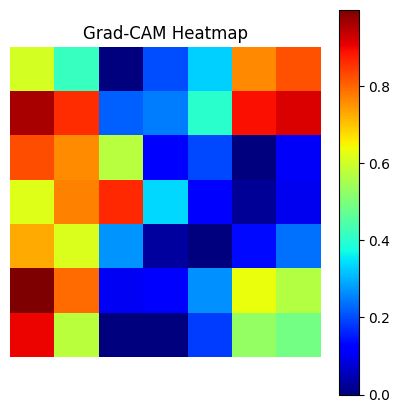

In [139]:
plt.figure(figsize=(5,5))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.colorbar()

plt.title("Grad-CAM Heatmap")

plt.axis("off")

plt.show()

In [140]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


heatmap_resized = cv2.resize(
    heatmap,
    (224,224)
)

In [141]:
heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)


heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

In [142]:
original_img = cv2.imread(img_path)

original_img = cv2.resize(
    original_img,
    (224,224)
)

In [143]:
superimposed_img = cv2.addWeighted(
    original_img,
    0.6,
    heatmap_color,
    0.4,
    0
)

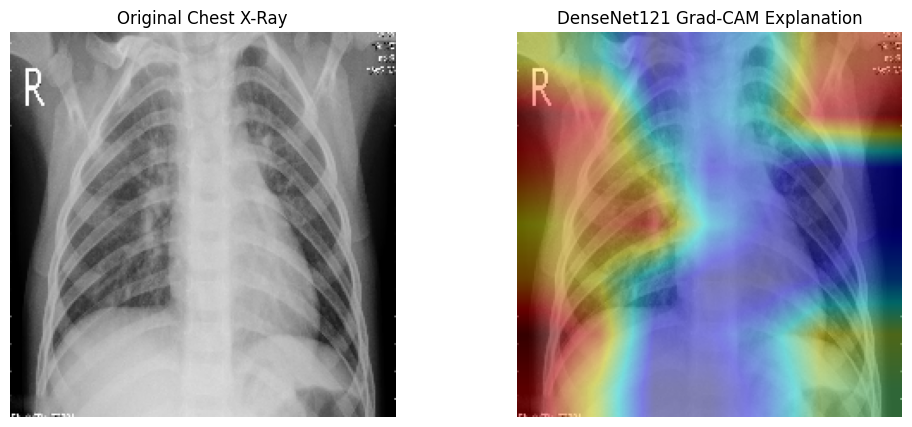

In [144]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)

plt.imshow(
    cv2.cvtColor(
        original_img,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Original Chest X-Ray"
)

plt.axis("off")



plt.subplot(1,2,2)

plt.imshow(
    cv2.cvtColor(
        superimposed_img,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "DenseNet121 Grad-CAM Explanation"
)

plt.axis("off")


plt.show()

# **Combined AI System**

In [145]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model

In [146]:
model = tf.keras.models.load_model(
    "best_densenet121_pneumonia_finetuned.keras"
)

In [147]:
last_conv_layer_name = "conv5_block16_concat"


grad_model = Model(

    inputs=model.input,

    outputs=[
        model.get_layer(last_conv_layer_name).output,
        model.output
    ]
)

In [148]:
def generate_gradcam(img_array):

    with tf.GradientTape() as tape:


        conv_outputs, predictions = grad_model(
            img_array
        )


        loss = predictions[:,0]


    grads = tape.gradient(
        loss,
        conv_outputs
    )


    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )


    conv_outputs = conv_outputs[0]


    heatmap = conv_outputs @ pooled_grads[...,None]


    heatmap = tf.squeeze(
        heatmap
    )


    heatmap = tf.maximum(
        heatmap,
        0
    )


    heatmap /= (
        tf.reduce_max(heatmap)
        + 1e-10
    )


    return heatmap.numpy()

In [149]:
def pneumonia_ai_system(image_path):


    # -------------------------
    # Load Image
    # -------------------------

    img = load_img(

        image_path,

        target_size=(224,224),

        color_mode="rgb"

    )


    img_array = img_to_array(img)


    img_array = img_array / 255.0


    input_image = np.expand_dims(
        img_array,
        axis=0
    )



    # -------------------------
    # Prediction
    # -------------------------

    prediction = model.predict(
        input_image
    )[0][0]


    if prediction >= 0.5:

        label = "PNEUMONIA"

        confidence = prediction


    else:

        label = "NORMAL"

        confidence = 1-prediction



    # -------------------------
    # Grad-CAM
    # -------------------------

    heatmap = generate_gradcam(
        input_image
    )


    heatmap = cv2.resize(
        heatmap,
        (224,224)
    )



    # -------------------------
    # Overlay
    # -------------------------

    original = cv2.imread(
        image_path
    )


    original = cv2.resize(
        original,
        (224,224)
    )


    heatmap_color = cv2.applyColorMap(

        np.uint8(255*heatmap),

        cv2.COLORMAP_JET

    )


    overlay = cv2.addWeighted(

        original,

        0.6,

        heatmap_color,

        0.4,

        0

    )



    # -------------------------
    # Display Result
    # -------------------------


    plt.figure(figsize=(12,5))


    plt.subplot(1,3,1)

    plt.imshow(
        cv2.cvtColor(
            original,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        "Original X-Ray"
    )

    plt.axis("off")



    plt.subplot(1,3,2)

    plt.imshow(
        cv2.cvtColor(
            overlay,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        "Grad-CAM Explanation"
    )

    plt.axis("off")



    plt.subplot(1,3,3)


    plt.text(

        0.1,

        0.5,

        f"""
AI REPORT


Prediction:
{label}


Confidence:
{confidence*100:.2f}%


Model:
DenseNet121


Explainability:
Grad-CAM
        """,

        fontsize=12

    )


    plt.axis("off")


    plt.show()



    return {

        "Prediction": label,

        "Confidence": confidence,

        "Model": "DenseNet121",

        "Explainability": "Grad-CAM"

    }

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


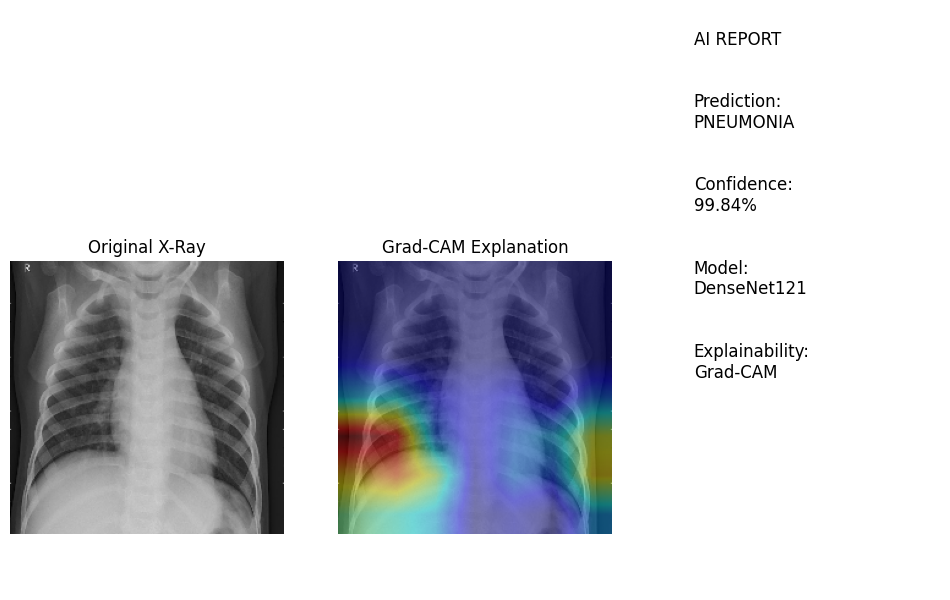

In [162]:
image_path = test_df[
    test_df["label"]==0
].iloc[4]["filepath"]


result = pneumonia_ai_system(
    image_path
)

# **Save Models**

In [166]:
model.save(
    "/content/best_densenet121_pneumonia_final.keras"
)

print("Model saved successfully!")

Model saved successfully!


In [167]:
import os

print(
    os.path.getsize(
        "/content/best_densenet121_pneumonia_final.keras"
    ) / (1024**2),
    "MB"
)

39.51986503601074 MB


In [168]:
from google.colab import files

files.download(
    "/content/best_densenet121_pneumonia_final.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [169]:
model.save_weights(
    "/content/densenet121_pneumonia_weights.weights.h5"
)